# 🏆 2026 FIFA World Cup Prediction Model
### Historical Data Analysis (1980–2026) · ELO Rating System · Match Forecasting

---

**Dataset** — [martj42/international_results](https://github.com/martj42/international_results)  
**Coverage** — All international football matches from 1980 through 2026  
**Engine** — Dynamic ELO with goal-difference multiplier + Poisson calibration  

---

In [1]:
import subprocess, sys

PACKAGES = ['requests', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy']
for pkg in PACKAGES:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed.')

✅ All packages installed.


In [2]:
import os, warnings, requests
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import poisson

warnings.filterwarnings('ignore')

DARK_BG  = '#0d1117';  PANEL_BG = '#161b22';  BORDER   = '#30363d'
TEXT_PRI = '#e6edf3';  TEXT_SEC = '#8b949e'
ACCENT1  = '#58a6ff';  ACCENT2  = '#f78166';  ACCENT3  = '#3fb950'
GOLD     = '#d29922';  PORTUGAL = '#e9272d'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,   'axes.facecolor': PANEL_BG,
    'axes.edgecolor':   BORDER,    'axes.labelcolor': TEXT_PRI,
    'axes.titlecolor':  TEXT_PRI,  'xtick.color': TEXT_SEC,
    'ytick.color':      TEXT_SEC,  'text.color': TEXT_PRI,
    'grid.color':       BORDER,    'grid.linestyle': '--',
    'grid.alpha':       0.4,       'font.size': 11,
    'axes.titlesize':   14,
    'legend.facecolor': PANEL_BG,  'legend.edgecolor': BORDER,
})
print('✅ Imports done. Dark theme configured.')

✅ Imports done. Dark theme configured.


---
## 📥 Section 1 — Data Ingestion

Downloads three CSV files from **martj42/international_results** on GitHub, cached under `datasets/`.

| File | Contents |
|---|---|
| `results.csv` | Match scores, date, teams, tournament, venue |
| `goalscorers.csv` | Individual goalscorer records |
| `shootouts.csv` | Penalty shootout outcomes |


In [3]:
BASE_URL  = 'https://raw.githubusercontent.com/martj42/international_results/master/'
DATASETS  = ['results.csv', 'goalscorers.csv', 'shootouts.csv']
LOCAL_DIR = 'datasets'

os.makedirs(LOCAL_DIR, exist_ok=True)

for fname in DATASETS:
    local_path = os.path.join(LOCAL_DIR, fname)
    if os.path.exists(local_path):
        print(f'  ↳ {fname:<26} [cached – skipping]')
        continue
    resp = requests.get(BASE_URL + fname, timeout=30)
    resp.raise_for_status()
    with open(local_path, 'wb') as fh:
        fh.write(resp.content)
    print(f'  ↳ {fname:<26} ✓  ({os.path.getsize(local_path)/1_024:.1f} KB)')

print()
print('✅ All datasets ready in ./datasets/')

  ↳ results.csv                [cached – skipping]
  ↳ goalscorers.csv            [cached – skipping]
  ↳ shootouts.csv              [cached – skipping]

✅ All datasets ready in ./datasets/


In [4]:
results_raw = pd.read_csv('datasets/results.csv',     parse_dates=['date'])
goalscorers = pd.read_csv('datasets/goalscorers.csv', parse_dates=['date'])
shootouts   = pd.read_csv('datasets/shootouts.csv',   parse_dates=['date'])

CUT_YEAR = 1980
results  = (results_raw[results_raw['date'].dt.year >= CUT_YEAR]
            .copy().reset_index(drop=True))

results['year']        = results['date'].dt.year
results['total_goals'] = results['home_score'] + results['away_score']
results['result']      = np.where(
    results['home_score'] > results['away_score'], 'Home Win',
    np.where(results['home_score'] < results['away_score'], 'Away Win', 'Draw')
)

wc_mask = (
    results['tournament'].str.contains('FIFA World Cup', case=False, na=False) &
    ~results['tournament'].str.contains('qualif', case=False, na=False)
)
wc = results[wc_mask].copy()

date_min = results['date'].min().date()
date_max = results['date'].max().date()
print(f'Total international matches (1980–2026) : {len(results):>6,}')
print(f'World Cup matches only                   : {len(wc):>6,}')
print(f'Date range                               : {date_min} → {date_max}')
print()
print('WC Tournaments found:')
for t in sorted(wc['tournament'].unique()):
    print(f'  • {t}')

Total international matches (1980–2026) : 37,406
World Cup matches only                   :    750
Date range                               : 1980-01-06 → 2026-07-06

WC Tournaments found:
  • FIFA World Cup


---
## 📊 Section 2 — Exploratory Data Analysis & Trend Mining

Six visualisations exposing structural patterns of World Cup football since 1980.

| # | Trend | Focus |
|---|---|---|
| 1 | Match Volume | Games per tournament |
| 2 | Scoring Trends | Is football becoming more or less open? |
| 3 | National Dominance | Top 15 nations by WC wins |
| 4 | Continental Power | UEFA vs CONMEBOL vs rest |
| 5 | Score Distribution | Empirical vs. Poisson model |
| 6 | Portugal Deep-Dive | The Ronaldo-era WC record 🇵🇹 |


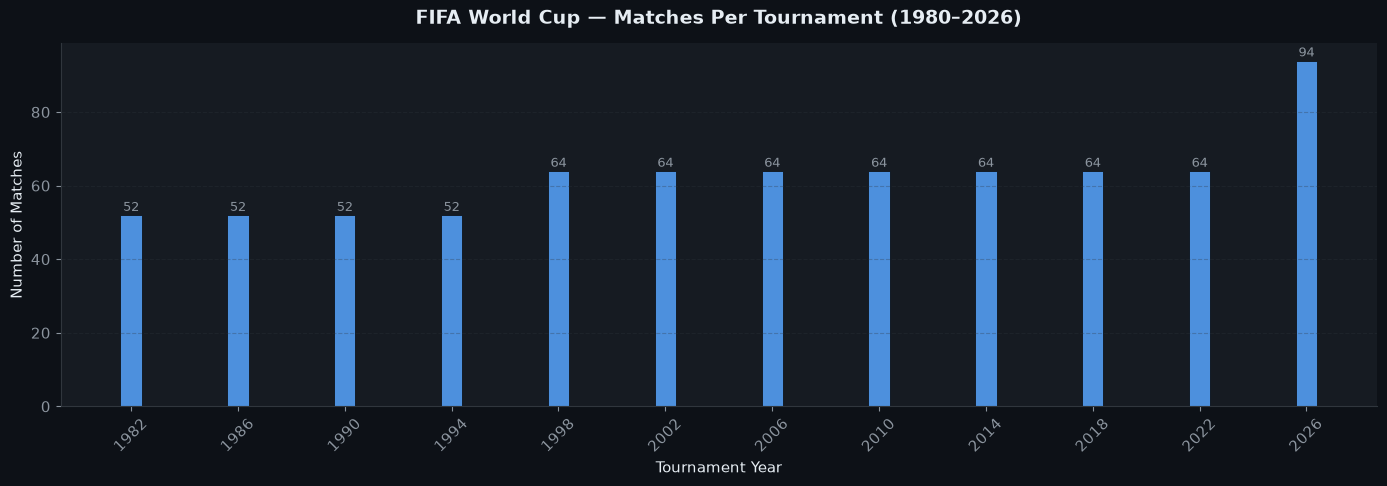

Note: 2026 expands to 104 matches — the first 48-team World Cup.


In [5]:
# ── Trend 1: Match Volume Per Tournament ──────────────────────────────────────
wc_per_year = wc.groupby('year').size().reset_index(name='matches')

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(DARK_BG)

bars = ax.bar(wc_per_year['year'], wc_per_year['matches'],
              color=ACCENT1, alpha=0.85, edgecolor=DARK_BG, linewidth=0.7)
for bar, val in zip(bars, wc_per_year['matches']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(int(val)), ha='center', va='bottom', fontsize=9, color=TEXT_SEC)

ax.set_title('FIFA World Cup — Matches Per Tournament (1980–2026)', fontweight='bold', pad=14)
ax.set_xlabel('Tournament Year');  ax.set_ylabel('Number of Matches')
ax.set_xticks(wc_per_year['year']);  ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3);  ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('datasets/trend_01_matches.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: 2026 expands to 104 matches — the first 48-team World Cup.')

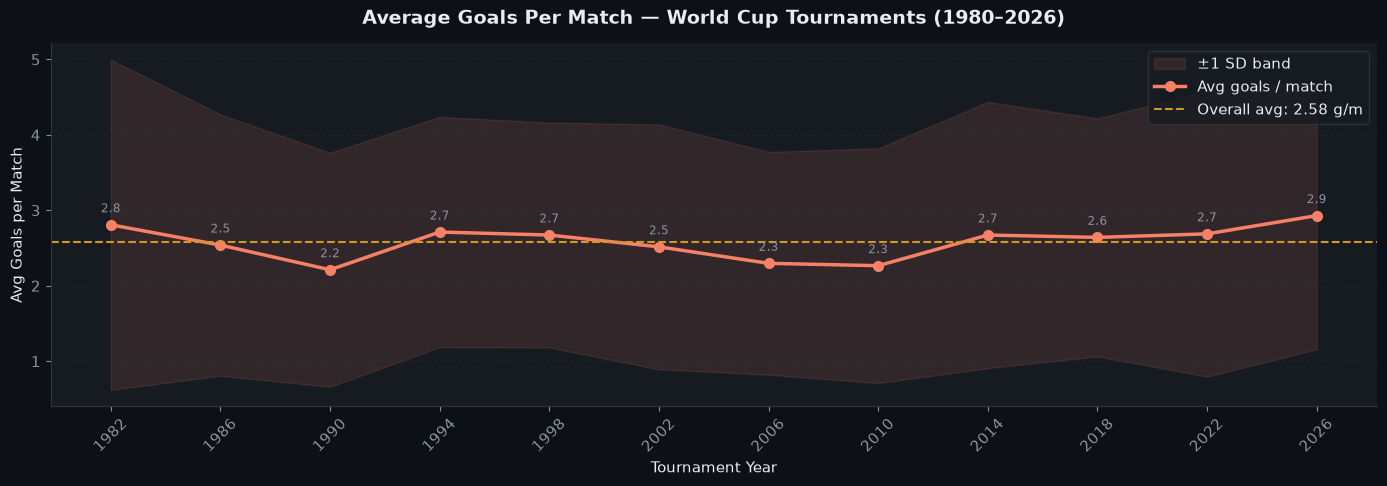

In [6]:
# ── Trend 2: Average Goals Per Match Across WC Tournaments ────────────────────
avg_goals   = wc.groupby('year')['total_goals'].agg(mean='mean', std='std').reset_index()
overall_avg = avg_goals['mean'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(DARK_BG)

ax.fill_between(
    avg_goals['year'],
    (avg_goals['mean'] - avg_goals['std'].fillna(0)).clip(lower=0),
    avg_goals['mean'] + avg_goals['std'].fillna(0),
    alpha=0.12, color=ACCENT2, label='±1 SD band'
)
ax.plot(avg_goals['year'], avg_goals['mean'],
        color=ACCENT2, linewidth=2.5, marker='o', markersize=7, label='Avg goals / match')
ax.axhline(overall_avg, color=GOLD, linestyle='--', linewidth=1.5,
           label=f'Overall avg: {overall_avg:.2f} g/m')

for _, row in avg_goals.iterrows():
    ax.annotate(f"{row['mean']:.1f}", (row['year'], row['mean']),
                textcoords='offset points', xytext=(0, 9),
                ha='center', fontsize=8.5, color=TEXT_SEC)

ax.set_title('Average Goals Per Match — World Cup Tournaments (1980–2026)', fontweight='bold', pad=14)
ax.set_xlabel('Tournament Year');  ax.set_ylabel('Avg Goals per Match')
ax.set_xticks(avg_goals['year']);  ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right');  ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('datasets/trend_02_avg_goals.png', dpi=150, bbox_inches='tight')
plt.show()

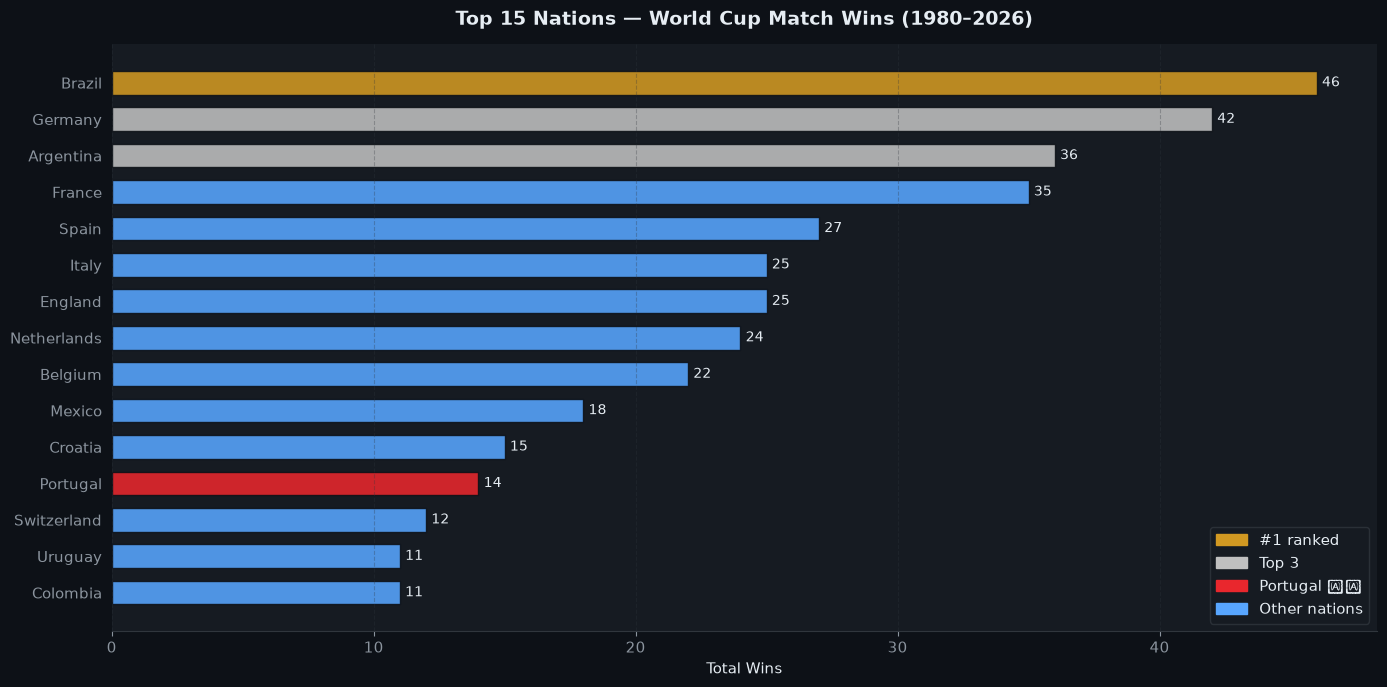

In [7]:
# ── Trend 3: Top 15 Nations by WC Match Wins ──────────────────────────────────
home_w  = wc[wc['result'] == 'Home Win'].groupby('home_team').size()
away_w  = wc[wc['result'] == 'Away Win'].groupby('away_team').size()
wc_wins = home_w.add(away_w, fill_value=0).astype(int).sort_values(ascending=False)
top15   = wc_wins.head(15)

bar_colors = [
    GOLD if i == 0 else '#c0c0c0' if i < 3 else PORTUGAL if team == 'Portugal' else ACCENT1
    for i, team in enumerate(top15.index)
]

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(DARK_BG)

bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color=bar_colors[::-1], alpha=0.88, edgecolor=DARK_BG, height=0.65)
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            str(int(val)), va='center', fontsize=10, color=TEXT_PRI)

ax.set_title('Top 15 Nations — World Cup Match Wins (1980–2026)', fontweight='bold', pad=14)
ax.set_xlabel('Total Wins')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False);  ax.tick_params(left=False)
patches = [
    mpatches.Patch(color=GOLD,      label='#1 ranked'),
    mpatches.Patch(color='#c0c0c0', label='Top 3'),
    mpatches.Patch(color=PORTUGAL,  label='Portugal 🇵🇹'),
    mpatches.Patch(color=ACCENT1,   label='Other nations'),
]
ax.legend(handles=patches, loc='lower right')
plt.tight_layout()
plt.savefig('datasets/trend_03_top_nations.png', dpi=150, bbox_inches='tight')
plt.show()

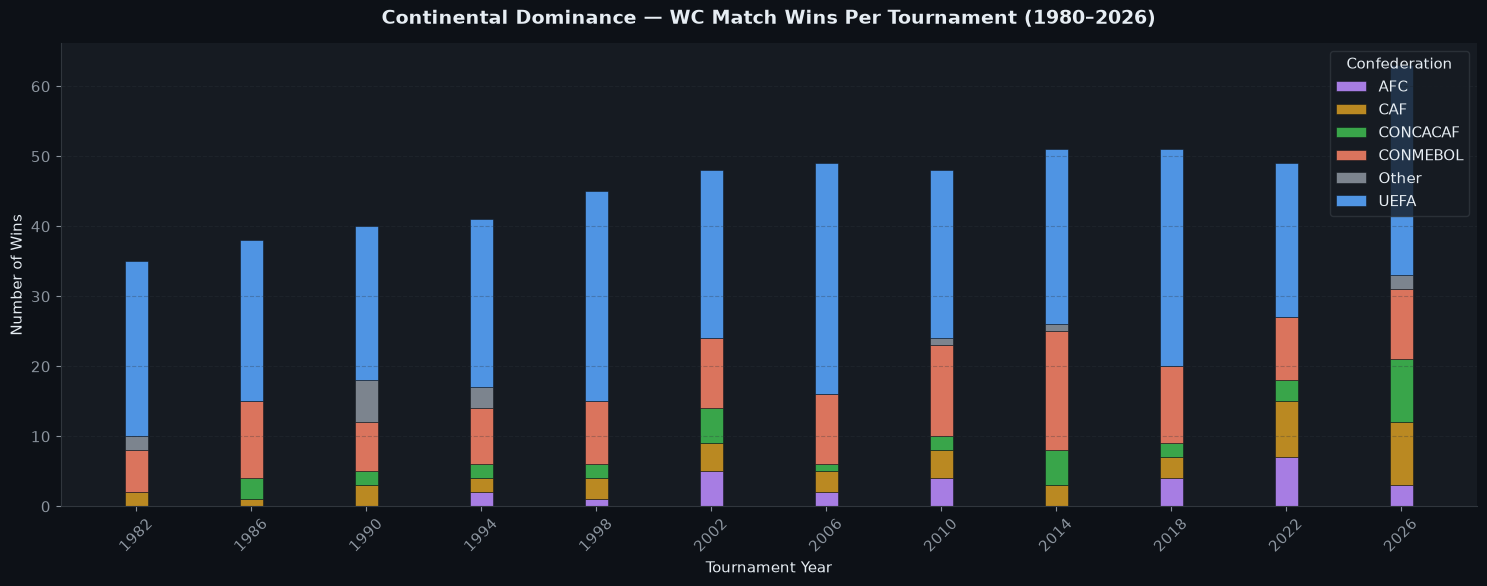

In [8]:
# ── Trend 4: Continental Dominance Over Time ──────────────────────────────────
CONF = {
    **dict.fromkeys(['Brazil','Argentina','Uruguay','Colombia','Chile',
                     'Paraguay','Ecuador','Peru','Bolivia','Venezuela'], 'CONMEBOL'),
    **dict.fromkeys(['Germany','France','Spain','Italy','England','Netherlands',
                     'Portugal','Belgium','Croatia','Czech Republic','Poland',
                     'Sweden','Denmark','Switzerland','Austria','Russia','Ukraine',
                     'Turkey','Serbia','Romania','Slovakia','Greece','Scotland',
                     'Wales','Republic of Ireland','Norway','Finland',
                     'Hungary','North Macedonia','Georgia'], 'UEFA'),
    **dict.fromkeys(['Mexico','United States','Canada','Costa Rica',
                     'Honduras','Jamaica','Trinidad and Tobago','Panama'], 'CONCACAF'),
    **dict.fromkeys(['Cameroon','Nigeria','Ghana','Senegal','Morocco',
                     'Ivory Coast','South Africa','Algeria','Egypt',
                     'Tunisia','Togo','Angola','Mali'], 'CAF'),
    **dict.fromkeys(['Japan','South Korea','Saudi Arabia','Iran','Australia',
                     'China PR','Qatar','Iraq'], 'AFC'),
    **dict.fromkeys(['New Zealand'], 'OFC'),
}
get_conf = lambda team: CONF.get(team, 'Other')

conf_rows = []
for _, row in wc.iterrows():
    if row['result'] == 'Home Win':
        conf_rows.append({'year': row['year'], 'conf': get_conf(row['home_team'])})
    elif row['result'] == 'Away Win':
        conf_rows.append({'year': row['year'], 'conf': get_conf(row['away_team'])})

conf_pivot = pd.DataFrame(conf_rows).groupby(['year','conf']).size().unstack(fill_value=0)
CONF_COLORS = {
    'UEFA': ACCENT1, 'CONMEBOL': ACCENT2, 'CONCACAF': ACCENT3,
    'CAF': GOLD, 'AFC': '#bc8cff', 'OFC': '#79c0ff', 'Other': TEXT_SEC,
}

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor(DARK_BG)
bottom = np.zeros(len(conf_pivot))
for col in conf_pivot.columns:
    vals = conf_pivot[col].values
    ax.bar(conf_pivot.index, vals, bottom=bottom, label=col,
           color=CONF_COLORS.get(col, TEXT_SEC), alpha=0.88, edgecolor=DARK_BG, linewidth=0.4)
    bottom += vals

ax.set_title('Continental Dominance — WC Match Wins Per Tournament (1980–2026)',
             fontweight='bold', pad=14)
ax.set_xlabel('Tournament Year');  ax.set_ylabel('Number of Wins')
ax.set_xticks(conf_pivot.index);  ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right', title='Confederation')
ax.grid(axis='y', alpha=0.3);  ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('datasets/trend_04_continental.png', dpi=150, bbox_inches='tight')
plt.show()

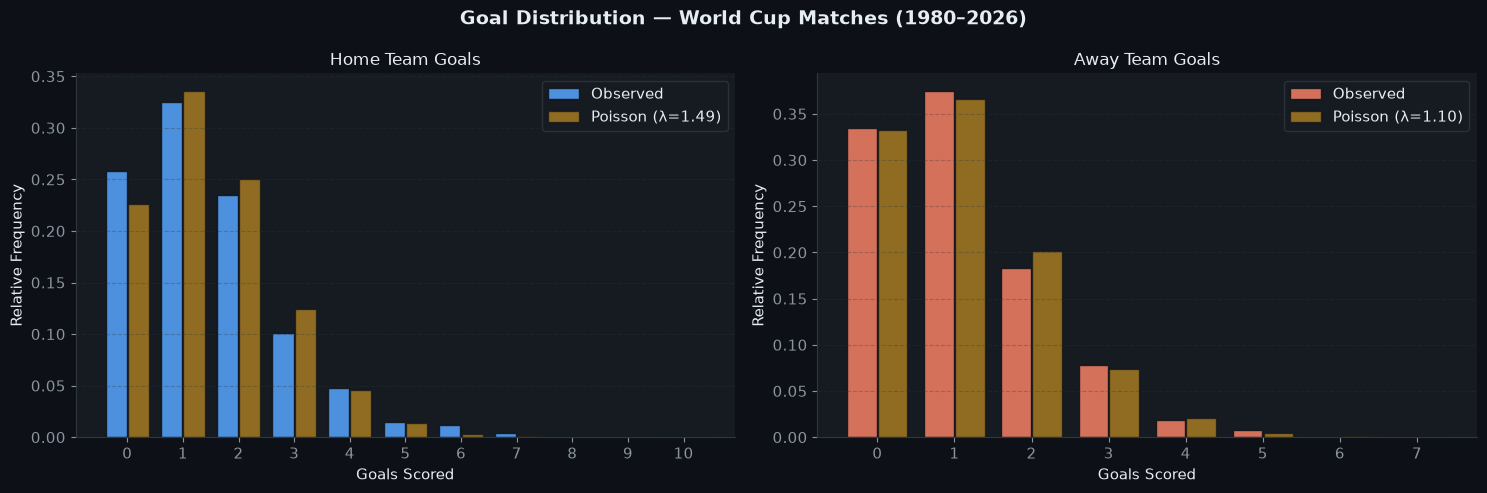

Poisson lambda  →  home: 1.487  |  away: 1.103


In [9]:
# ── Trend 5: Goal Distribution vs Poisson Model ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Goal Distribution — World Cup Matches (1980–2026)', fontweight='bold', fontsize=14)

for ax, col, title, color in zip(
    axes,
    ['home_score', 'away_score'],
    ['Home Team Goals', 'Away Team Goals'],
    [ACCENT1, ACCENT2]
):
    data      = wc[col].dropna().astype(int)
    mu        = data.mean()
    max_goals = min(data.max(), 10)
    x         = np.arange(0, max_goals + 1)
    observed  = data.value_counts().sort_index().reindex(x, fill_value=0) / len(data)
    pois_pmf  = poisson.pmf(x, mu)

    ax.bar(x - 0.2, observed, width=0.38, label='Observed',
           color=color, alpha=0.85, edgecolor=DARK_BG)
    ax.bar(x + 0.2, pois_pmf, width=0.38, label=f'Poisson (λ={mu:.2f})',
           color=GOLD, alpha=0.65, edgecolor=DARK_BG)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Goals Scored');  ax.set_ylabel('Relative Frequency')
    ax.set_xticks(x);  ax.legend()
    ax.grid(axis='y', alpha=0.3);  ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('datasets/trend_05_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()
lam_h = wc['home_score'].mean()
lam_a = wc['away_score'].mean()
print(f'Poisson lambda  →  home: {lam_h:.3f}  |  away: {lam_a:.3f}')

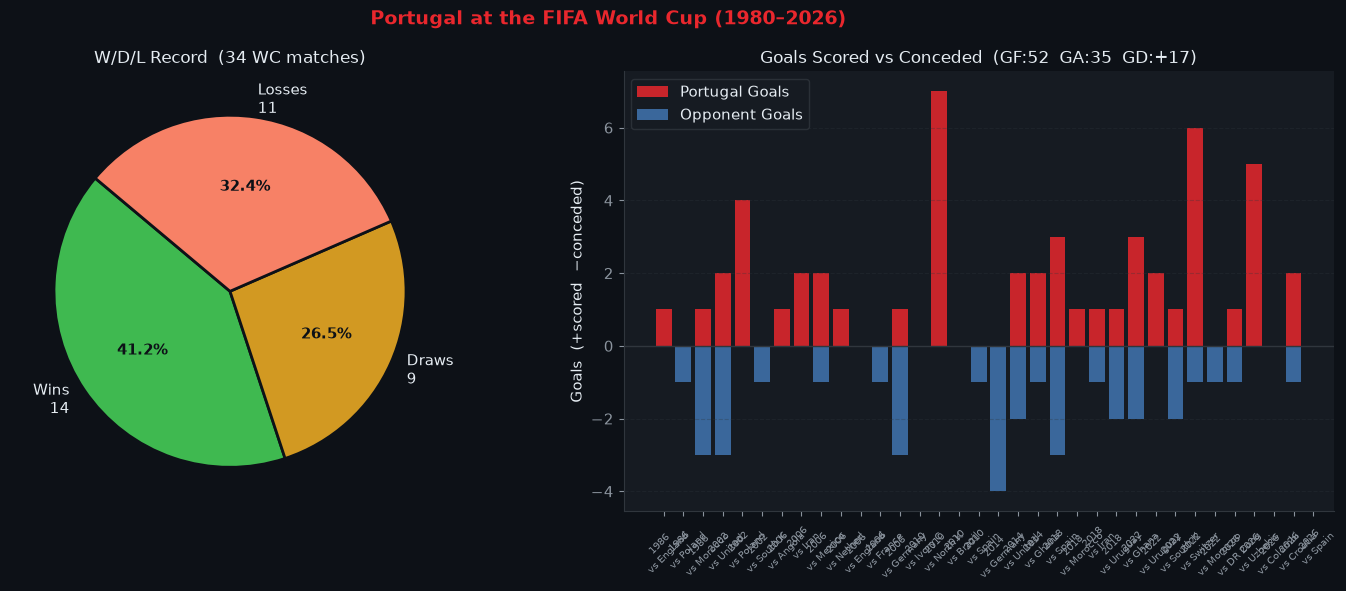

Portugal WC Summary: P34 W14 D9 L11 | GF:52 GA:35 GD:+17


In [10]:
from matplotlib import colors
# ── Trend 6: Portugal at the World Cup — Ronaldo Era (1980–2026) ──────────────
port_wc = wc[(wc['home_team'] == 'Portugal') | (wc['away_team'] == 'Portugal')].copy()
port_wc['port_goals']  = np.where(port_wc['home_team'] == 'Portugal',
                                   port_wc['home_score'], port_wc['away_score'])
port_wc['opp_goals']   = np.where(port_wc['home_team'] == 'Portugal',
                                   port_wc['away_score'], port_wc['home_score'])
port_wc['opponent']    = np.where(port_wc['home_team'] == 'Portugal',
                                   port_wc['away_team'], port_wc['home_team'])
port_wc['port_result'] = np.where(
    port_wc['port_goals'] > port_wc['opp_goals'], 'Win',
    np.where(port_wc['port_goals'] < port_wc['opp_goals'], 'Loss', 'Draw')
)

P, W = len(port_wc), (port_wc['port_result'] == 'Win').sum()
D, L = (port_wc['port_result'] == 'Draw').sum(), (port_wc['port_result'] == 'Loss').sum()
GF, GA = int(port_wc['port_goals'].sum()), int(port_wc['opp_goals'].sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Portugal at the FIFA World Cup (1980–2026)',
             fontweight='bold', fontsize=14, color=PORTUGAL)

wedges, texts, autotexts = ax1.pie(
        [W, D, L],
    labels=[f'Wins\n{W}', f'Draws\n{D}', f'Losses\n{L}'],
    colors=[ACCENT3, GOLD, ACCENT2],
    autopct='%1.1f%%', startangle=140,
    textprops={'color': TEXT_PRI, 'fontsize': 11},
    wedgeprops={'edgecolor': DARK_BG, 'linewidth': 2}
)

for at in autotexts:
    at.set_color(DARK_BG);  at.set_fontweight('bold')
ax1.set_title(f'W/D/L Record  ({P} WC matches)', fontsize=12)

port_sorted = port_wc.sort_values('year').reset_index(drop=True)
x_idx = range(len(port_sorted))
ax2.bar(x_idx,  port_sorted['port_goals'], color=PORTUGAL, alpha=0.85, label='Portugal Goals')
ax2.bar(x_idx, -port_sorted['opp_goals'],  color=ACCENT1,  alpha=0.55, label='Opponent Goals')
ax2.axhline(0, color=BORDER, linewidth=1)

tick_labels = [str(int(r['year'])) + '\nvs ' + str(r['opponent'])[:7]
               for _, r in port_sorted.iterrows()]

ax2.set_xticks(list(x_idx));  ax2.set_xticklabels(tick_labels, rotation=45, fontsize=7.5)
ax2.set_title(f'Goals Scored vs Conceded  (GF:{GF}  GA:{GA}  GD:{GF-GA:+})', fontsize=12)
ax2.set_ylabel('Goals  (+scored  −conceded)')
ax2.legend(loc='upper left')
ax2.grid(axis='y', alpha=0.3);  ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('datasets/trend_06_portugal.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Portugal WC Summary: P{P} W{W} D{D} L{L} | GF:{GF} GA:{GA} GD:{GF-GA:+}')

---
## ⚙️ Section 3 — ELO Rating Engine

A dynamic ELO system trained chronologically on **all** international matches from 1980 to 2026.

| Parameter | Detail |
|---|---|
| Starting ELO | 1500 for every nation |
| K-factor range | 20 (Friendly) → 64 (WC Final) |
| Goal-difference multiplier | 1.0× → 1.75× → scaled beyond 3 goals |
| Training scope | All international matches 1980–2026 |


In [11]:
INITIAL_ELO = 1500.0

def expected_score(ra: float, rb: float) -> float:
    # Standard ELO expected win probability for team A vs team B
    return 1.0 / (1.0 + 10.0 ** ((rb - ra) / 400.0))


def goal_diff_multiplier(gd: int) -> float:
    # Scale the update magnitude by margin of victory (caps to prevent rating runaway)
    gd = abs(gd)
    if   gd <= 1: return 1.00
    elif gd == 2: return 1.50
    elif gd == 3: return 1.75
    else:         return 1.75 + 0.05 * (gd - 3)


def k_factor(tournament: str) -> float:
    # K-factor by tournament prestige — higher stakes → larger ELO shifts
    t = tournament.lower()
    if 'world cup' in t and 'qualif' not in t:
        return 64.0 if 'final' in t else 50.0
    if 'qualif' in t:
        return 35.0
    if any(c in t for c in ['euro', 'copa america', 'africa cup',
                              'gold cup', 'asian cup', 'confederation']):
        return 45.0
    if 'friendly' in t:
        return 20.0
    return 30.0


def update_elo(ra, rb, score_a, score_b, tournament):
    # Apply one ELO update step, return updated (ra, rb)
    K   = k_factor(tournament)
    GDM = goal_diff_multiplier(abs(score_a - score_b))
    if   score_a > score_b: sa, sb = 1.0, 0.0
    elif score_a < score_b: sa, sb = 0.0, 1.0
    else:                   sa, sb = 0.5, 0.5
    Ea = expected_score(ra, rb)
    Eb = expected_score(rb, ra)
    return ra + K * GDM * (sa - Ea), rb + K * GDM * (sb - Eb)


print('✅ ELO engine functions ready.')
print()
for label, tourn in [
    ('World Cup Final       ', 'FIFA World Cup Final'),
    ('World Cup Group/KO    ', 'FIFA World Cup'),
    ('WC Qualifier          ', 'FIFA World Cup qualification'),
    ('Continental (Euro)    ', 'UEFA Euro'),
    ('Friendly              ', 'Friendly match'),
]:
    print(f'  {label} → K = {k_factor(tourn):.0f}')

✅ ELO engine functions ready.

  World Cup Final        → K = 64
  World Cup Group/KO     → K = 50
  WC Qualifier           → K = 35
  Continental (Euro)     → K = 45
  Friendly               → K = 20


In [12]:
# Chronological ELO training on ALL international matches (1980–2026)
elo_ratings = defaultdict(lambda: INITIAL_ELO)

training_set = results.dropna(subset=['home_score', 'away_score']).sort_values('date')

for _, row in training_set.iterrows():
    ht, at  = row['home_team'], row['away_team']
    hs, as_ = int(row['home_score']), int(row['away_score'])
    new_ra, new_rb = update_elo(
        elo_ratings[ht], elo_ratings[at], hs, as_, row['tournament']
    )
    elo_ratings[ht] = new_ra
    elo_ratings[at] = new_rb

elo_series = pd.Series(dict(elo_ratings)).sort_values(ascending=False)

print(f'✅ ELO training complete.')
print(f'   Matches processed : {len(training_set):,}')
print(f'   Teams rated       : {len(elo_series)}')
print()
print('🏆 Top 20 ELO Rankings:')
print('─' * 44)
for rank, (team, rating) in enumerate(elo_series.head(20).items(), 1):
    marker = '  🐐' if team == 'Portugal' else ''
    print(f'  {rank:2d}. {team:<26} {rating:>8,.1f}{marker}')

✅ ELO training complete.
   Matches processed : 37,397
   Teams rated       : 330

🏆 Top 20 ELO Rankings:
────────────────────────────────────────────
   1. Spain                       2,176.2
   2. Argentina                   2,173.8
   3. France                      2,149.6
   4. England                     2,081.1
   5. Brazil                      2,074.5
   6. Colombia                    2,041.9
   7. Mexico                      2,039.5
   8. Portugal                    2,036.8  🐐
   9. Netherlands                 2,029.2
  10. Morocco                     2,014.2
  11. Germany                     1,988.0
  12. Switzerland                 1,983.8
  13. Japan                       1,973.7
  14. Belgium                     1,964.3
  15. Norway                      1,961.4
  16. United States               1,948.2
  17. Ecuador                     1,919.7
  18. Croatia                     1,919.3
  19. Italy                       1,908.2
  20. Denmark                     1,894.2


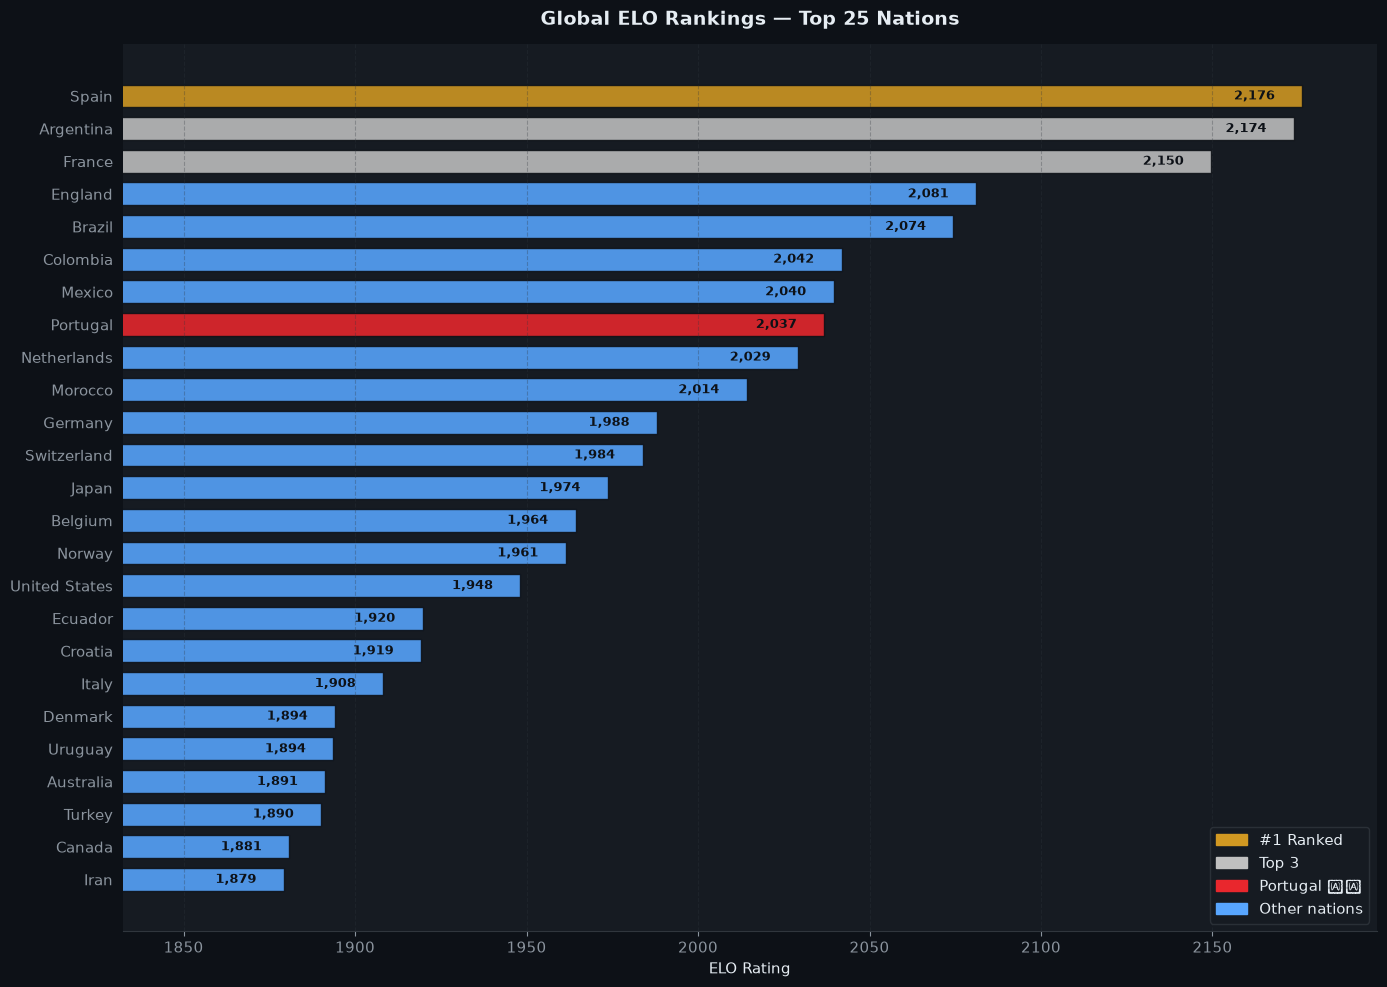

In [13]:
# ELO Leaderboard — Top 25 Visualisation
top25 = elo_series.head(25)

bar_colors = [
    GOLD if i == 0 else '#c0c0c0' if i < 3 else PORTUGAL if team == 'Portugal' else ACCENT1
    for i, team in enumerate(top25.index)
]

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor(DARK_BG)

bars = ax.barh(top25.index[::-1], top25.values[::-1],
               color=bar_colors[::-1], alpha=0.88, edgecolor=DARK_BG, height=0.7)
for bar, val in zip(bars, top25.values[::-1]):
    ax.text(bar.get_width() - 8, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', ha='right',
            fontsize=9.5, color=DARK_BG, fontweight='bold')

ax.set_title('Global ELO Rankings — Top 25 Nations', fontweight='bold', fontsize=14, pad=14)
ax.set_xlabel('ELO Rating')
ax.set_xlim(top25.min() * 0.975, top25.max() * 1.01)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False);  ax.tick_params(left=False)
patches = [
    mpatches.Patch(color=GOLD,      label='#1 Ranked'),
    mpatches.Patch(color='#c0c0c0', label='Top 3'),
    mpatches.Patch(color=PORTUGAL,  label='Portugal 🇵🇹'),
    mpatches.Patch(color=ACCENT1,   label='Other nations'),
]
ax.legend(handles=patches, loc='lower right')
plt.tight_layout()
plt.savefig('datasets/elo_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔮 Section 4 — 2026 Match Predictor

Type two team names to get:
- Both teams' **ELO rating** (the model's current power estimate)
- **Win / Draw / Loss probabilities** calibrated to historical WC draw rates

> 🐐 *Portugal activates a special Ronaldo tribute.*


In [16]:
HISTORICAL_DRAW_RATE = wc['result'].value_counts(normalize=True).get('Draw', 0.22)


def predict_match(team_a: str, team_b: str) -> dict:
    ra = elo_ratings.get(team_a, INITIAL_ELO)
    rb = elo_ratings.get(team_b, INITIAL_ELO)

    if team_a not in elo_ratings:
        print(f'  ⚠  {team_a!r} not found — using default ELO {INITIAL_ELO:.0f}')
    if team_b not in elo_ratings:
        print(f'  ⚠  {team_b!r} not found — using default ELO {INITIAL_ELO:.0f}')

    e_a = expected_score(ra, rb)
    e_b = expected_score(rb, ra)

    # Partition probability mass: draw absorbs empirically calibrated fraction;
    # remainder is split proportionally between the two win outcomes.
    raw_win_a = e_a * (1 - HISTORICAL_DRAW_RATE)
    raw_win_b = e_b * (1 - HISTORICAL_DRAW_RATE)
    raw_draw  = HISTORICAL_DRAW_RATE
    total     = raw_win_a + raw_win_b + raw_draw

    win_a = raw_win_a / total * 100
    draw  = raw_draw  / total * 100
    win_b = raw_win_b / total * 100

    favourite = (team_a if win_a > win_b else
                 team_b if win_b > win_a else 'Too Close to Call')

    return {'elo_a': ra, 'elo_b': rb,
            'win_a': win_a, 'draw': draw, 'win_b': win_b,
            'favourite': favourite}


def display_prediction(team_a: str, team_b: str) -> None:
    r   = predict_match(team_a, team_b)
    SEP = '=' * 55
    sep = '-' * 55

    print(); print(SEP)
    print('  2026 FIFA WORLD CUP — MATCH PREDICTION')
    print(SEP)
    print(f'  {"Team":<32} {"ELO Rating":>10}')
    print(sep)
    print(f'  {team_a:<32} {r["elo_a"]:>10,.1f}')
    print(f'  {team_b:<32} {r["elo_b"]:>10,.1f}')
    print(sep)
    print(f'  {"Outcome":<32} {"Probability":>10}')
    print(sep)
    print(f'  {team_a + " Win":<32} {r["win_a"]:>9.1f}%')
    print(f'  {"Draw":<32} {r["draw"]:>9.1f}%')
    print(f'  {team_b + " Win":<32} {r["win_b"]:>9.1f}%')
    print(SEP)
    print(f'  Prediction: {r["favourite"].upper()} are favoured to win')
    print(SEP)

    if 'Portugal' in (team_a, team_b):
        print()
        print('  🐐 RONALDO TRIBUTE')
        print('  ' + '-' * 40)
        print('  Cristiano Ronaldo — World Cup career:')
        print('    Tournaments : 2006  2010  2014  2018  2022')
        print('    Goals: 8  |  Assists: 3')
        print('    Best result : 3rd Place (2006 Germany)')
        print('    2022 Qatar  : Quarterfinal (lost to Morocco)')
        print('  Portugal is a dangerous dark horse in 2026. 🇵🇹')
        print('  ' + '-' * 40)


print('✅ Prediction engine ready.')
print(f'   Historical WC draw rate used : {HISTORICAL_DRAW_RATE:.1%}')

✅ Prediction engine ready.
   Historical WC draw rate used : 25.6%


In [17]:
# 🔮 Run Your 2026 World Cup Match Prediction
# ──────────────────────────────────────────────
# Use team names exactly as shown in the list below.

sample = sorted(elo_series.head(40).index.tolist())
print('Top 40 ELO-ranked teams:')
for i in range(0, len(sample), 4):
    print('  ' + '  |  '.join(f'{t:<22}' for t in sample[i:i+4]))
print()

team_a = input('Enter Team 1 : ').strip()
team_b = input('Enter Team 2 : ').strip()

display_prediction(team_a, team_b)

Top 40 ELO-ranked teams:
  Algeria                 |  Argentina               |  Australia               |  Austria               
  Belgium                 |  Brazil                  |  Canada                  |  Colombia              
  Croatia                 |  Denmark                 |  Ecuador                 |  Egypt                 
  England                 |  France                  |  Germany                 |  Iran                  
  Italy                   |  Ivory Coast             |  Japan                   |  Jersey                
  Mexico                  |  Morocco                 |  Netherlands             |  Nigeria               
  Norway                  |  Paraguay                |  Portugal                |  Russia                
  Scotland                |  Senegal                 |  Serbia                  |  South Korea           
  Spain                   |  Sweden                  |  Switzerland             |  Turkey                
  Ukraine            